# PCL Detector

We aim to develop a model that can detect patronising and condescending language (PCL) in text, particularly in online news articles about vulnerable communities. This task is important for promoting respectful and inclusive communication, and for identifying and addressing instances of PCL in media coverage.

## Setup

In [174]:
%pip install -q -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")


In [176]:
PCL_TSV        = "assets/NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
CATEGORIES_TSV = "data/train/dontpatronizeme_categories.tsv"
TRAIN_SPLIT    = "data/splits/train_semeval_parids-labels.csv"
DEV_SPLIT      = "data/splits/dev_semeval_parids-labels.csv"

### Data Preprocessing

In [177]:
# ── Load PCL binary dataset (skip 4-line disclaimer header) ───────────────────
def load_pcl_dataset(tsv_path):
    df_pcl = pd.read_csv(
        tsv_path, sep="\t", skiprows=4, header=None,
        names=["par_id", "art_id", "keyword", "country_code", "text", "label"]
    )
    df_pcl["par_id"] = df_pcl["par_id"].astype(int)
    df_pcl["label"]  = df_pcl["label"].astype(int)
    return df_pcl

def load_categories_dataset(tsv_path):
    df_cat = pd.read_csv(
        tsv_path, sep="\t", skiprows=4, header=None,
        names=["par_id","art_id","text","keyword","country_code",
               "span_start","span_finish","span_text","pcl_category","num_annotators"]
    )
    return df_cat

The *PCL binary classification dataset* contains paragraphs annotated with a
label from 0 (not containing PCL) to 4 (being highly patronizing or
condescending) towards vulnerable communities. It contains one instance per line
with the following format:	
  - `<par_id>` is a unique id for each one of the paragraphs in the corpus.
  - `<art_id>` is the document id in the original NOW corpus (News on Web:
    https://www.english-corpora.org/now/).
  - `<keyword>` is the search term used to retrieve texts about a target
    community.
  - `<country_code>` is a two-letter ISO Alpha-2 country code for the source media
    outlet.
  - `<text>` is the paragraph containing the keyword.
  - `<label>` is an integer between 0 and 4. Each paragraph has been annotated by
    two annotators as 0 (No PCL), 1 (borderline PCL) and 2 (contains PCL). The
    combined annotations have been used in the following graded scale:
    - 0 -> Annotator 1 = 0 AND Annotator 2 = 0
    - 1 -> Annotator 1 = 0 AND Annotator 2 = 1 OR Annotator 1 = 1 AND Annotator
      2 = 0
    - 2 -> Annotator 1 = 1 AND Annotator 2 = 1
    - 3 -> Annotator 1 = 1 AND Annotator 2 = 2 OR Annotator 1 = 2 AND Annotator
      2 = 1
    - 4 -> Annotator 1 = 2 AND Annotator 2 = 2
- The experiments reported in the paper consider the following tag grouping: 
  - {0,1}   = No PCL
  - {2,3,4} = PCL

The *PCL multilabel classification* dataset contains one instance per line with
the following format:
  - `<par_id>` is a unique id for each one of the paragraphs in the corpus
    (matching the ids of the dontpatronizeme_pcl subdataset).
  - `<art_id>` is the document id in the original NOW corpus (News on Web:
    https://www.english-corpora.org/now/).
  - `<text>` is the paragraph containing the keyword.
  - `<keyword>` is the search term used to retrieve texts about a target
    community.
  - `<country_code>` is a two-letter ISO Alpha-2 country code for the source media
    outlet.
  - `<span_start>` is the start character position of the span identified as pcl.
  - `<span_finish>` is the end character position of the span identified as pcl.
  - `<span_text>` is the span identified as pcl.
  - `<pcl_category>` is the pcl category** of the `<text_span>` at position
    `<text>[<span_start>:<span_finish>]`
  - `<number_of_annotators>` is the number of annotators agreeing on that `<pcl_category>` (1 or 2).

In [178]:
df_pcl = load_pcl_dataset(PCL_TSV)
df_cat = load_categories_dataset(CATEGORIES_TSV)

print(f"\ndf_pcl columns:  {list(df_pcl.columns)}")
print(f"df_cat columns:  {list(df_cat.columns)}")


df_pcl columns:  ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label']
df_cat columns:  ['par_id', 'art_id', 'text', 'keyword', 'country_code', 'span_start', 'span_finish', 'span_text', 'pcl_category', 'num_annotators']


In [179]:
# ── Load SemEval splits ────────────────────────────────────────────────────────
df_train_split = pd.read_csv(TRAIN_SPLIT)
df_dev_split   = pd.read_csv(DEV_SPLIT)

# Parse label vectors
df_train_split["label_vec"] = df_train_split["label"].apply(ast.literal_eval)
df_dev_split["label_vec"]   = df_dev_split["label"].apply(ast.literal_eval)

# ── Attach split membership to PCL dataframe ──────────────────────────────────
train_ids = set(df_train_split["par_id"])
dev_ids   = set(df_dev_split["par_id"])
df_pcl["split"] = df_pcl["par_id"].map(
    lambda x: "train" if x in train_ids else ("dev" if x in dev_ids else "unlabelled")
)
df_split = df_pcl[df_pcl["split"].isin(["train", "dev"])].copy()

# Binary PCL label (0/1) using the {0,1} → No PCL, {2,3,4} → PCL grouping
df_split["pcl"] = (df_split["label"] >= 2).astype(int)

# Split into train and test dfs
df_train = df_split[df_split.split=='train']
df_test = df_split[df_split.split=='dev']

print(f"PCL dataset:          {len(df_pcl):,} paragraphs")
print(f"  └─ train split:     {len(df_train)}")
print(f"  └─ dev   split:     {len(df_test)}")
print(f"Categories dataset:   {len(df_cat):,} annotated spans")

PCL dataset:          10,469 paragraphs
  └─ train split:     8375
  └─ dev   split:     2094
Categories dataset:   2,760 annotated spans


In [180]:
df_train.head(3)

,par_id,art_id,keyword,country_code,text,label,split,pcl
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,train,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,train,0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0,train,0


In [181]:
df_test.head(3)

,par_id,art_id,keyword,country_code,text,label,split,pcl
106,107,@@16900972,homeless,ke,"His present "" chambers "" may be quite humble ,...",3,dev,1
148,149,@@1387882,disabled,us,Krueger recently harnessed that creativity to ...,2,dev,1
150,151,@@19974860,poor-families,in,10:41am - Parents of children who died must ge...,3,dev,1


In [182]:
df_cat.head(3)

,par_id,art_id,text,keyword,country_code,span_start,span_finish,span_text,pcl_category,num_annotators
0,4046,@@14767805,We also know that they can benefit by receivin...,hopeless,us,201,236,put their situation in perspective,Authority_voice,2
1,4046,@@14767805,We also know that they can benefit by receivin...,hopeless,us,240,274,help them communicate with others,Unbalanced_power_relations,2
2,4046,@@14767805,We also know that they can benefit by receivin...,hopeless,us,274,300,who could provide support,Unbalanced_power_relations,1


## Exploratory Data Analysis

### Label Distribution

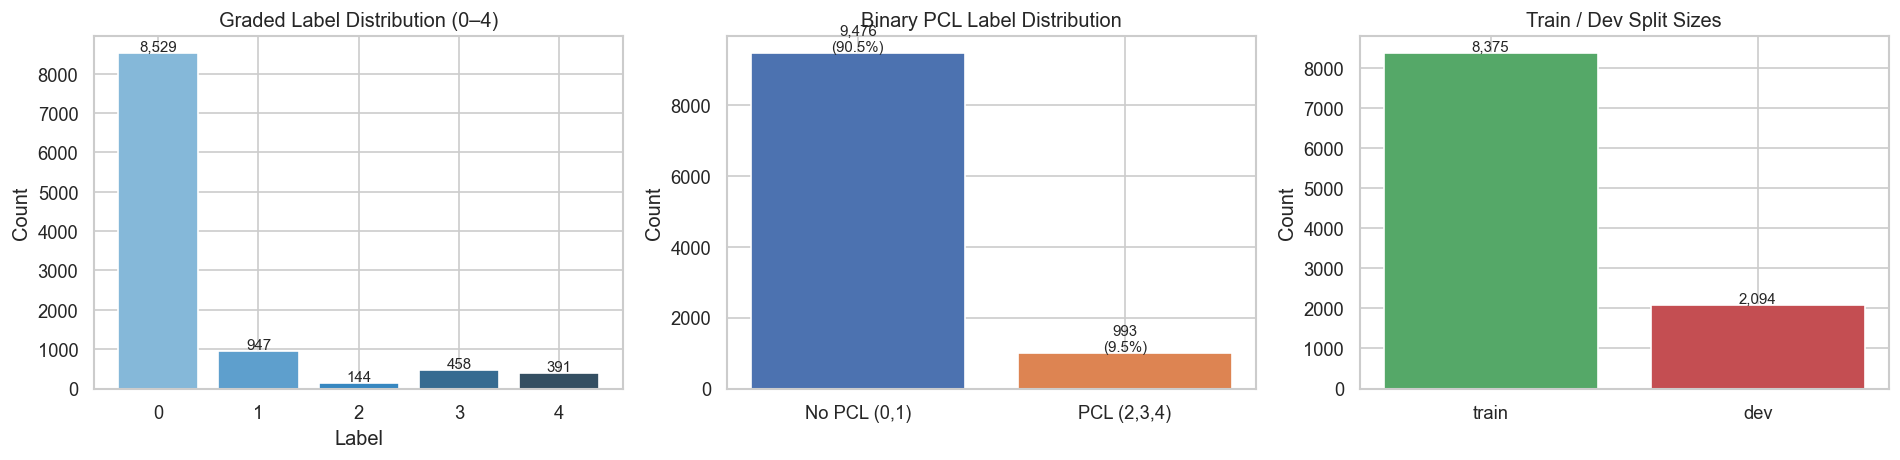

In [183]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Graded label distribution (0-4)
label_counts = df_split["label"].value_counts().sort_index()
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette("Blues_d", 5))
axes[0].set_title("Graded Label Distribution (0–4)")
axes[0].set_xlabel("Label"); axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}", ha="center", fontsize=9)

# 2. Binary PCL distribution
binary_counts = df_split["pcl"].value_counts().sort_index()
axes[1].bar(["No PCL (0,1)", "PCL (2,3,4)"], binary_counts.values,
            color=["#4c72b0", "#dd8452"])
axes[1].set_title("Binary PCL Label Distribution")
axes[1].set_ylabel("Count")
for bar, val in zip(axes[1].patches, binary_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}\n({val/len(df_split)*100:.1f}%)", ha="center", fontsize=9)

# 3. Train vs Dev split size
split_counts = df_split["split"].value_counts()
axes[2].bar(split_counts.index, split_counts.values, color=["#55a868", "#c44e52"])
axes[2].set_title("Train / Dev Split Sizes")
axes[2].set_ylabel("Count")
for bar, val in zip(axes[2].patches, split_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


In [184]:
print(f"\nClass imbalance ratio (No PCL : PCL): {binary_counts[0]/binary_counts[1]:.1f} : 1")


Class imbalance ratio (No PCL : PCL): 9.5 : 1


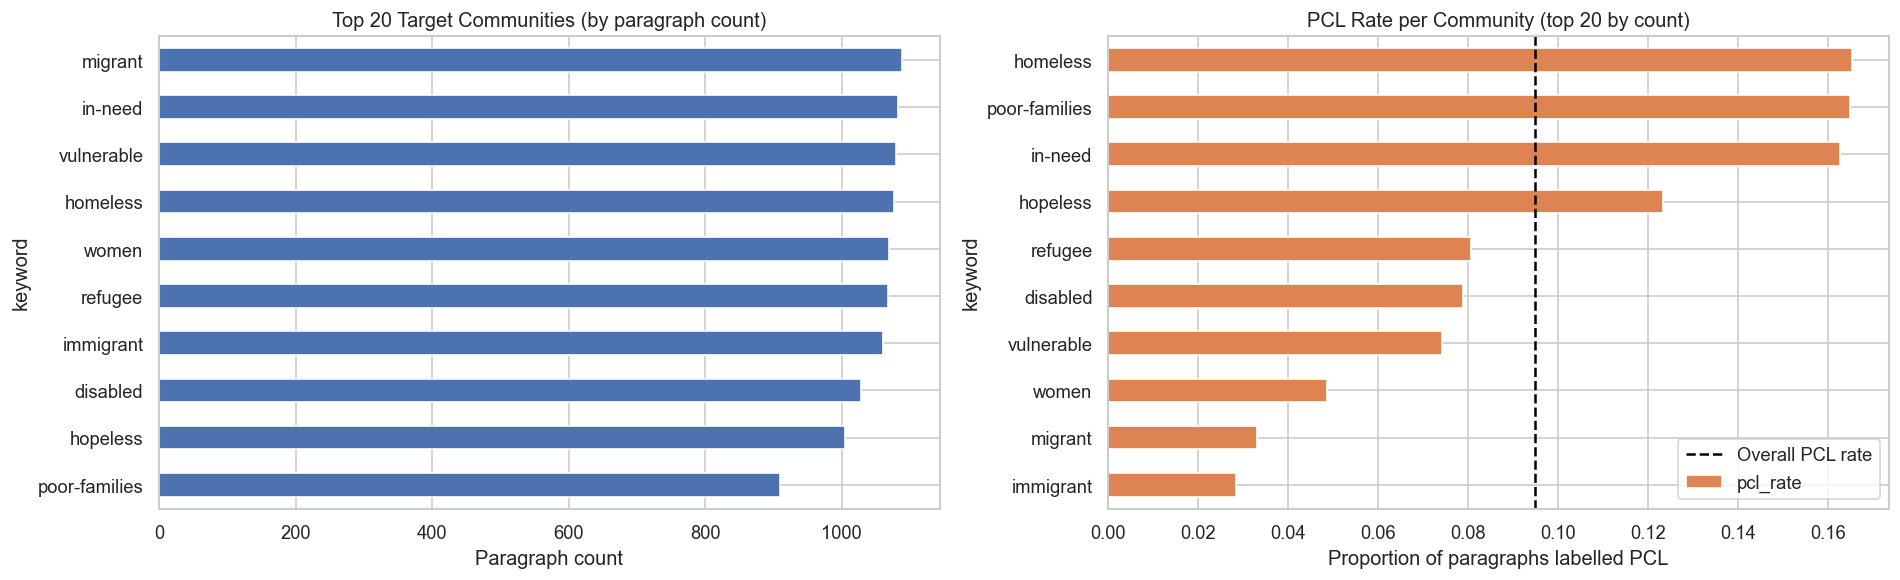

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top communities (keywords)
kw_pcl_rate = (
    df_split.groupby("keyword")["pcl"]
    .agg(count="count", pcl_rate="mean")
    .sort_values("count", ascending=False)
    .head(20)
)
kw_pcl_rate["count"].sort_values().plot.barh(ax=axes[0], color="#4c72b0")
axes[0].set_title("Top 20 Target Communities (by paragraph count)")
axes[0].set_xlabel("Paragraph count")

# PCL rate per community (top 20 by count)
kw_pcl_rate["pcl_rate"].sort_values().plot.barh(ax=axes[1], color="#dd8452")
axes[1].set_title("PCL Rate per Community (top 20 by count)")
axes[1].set_xlabel("Proportion of paragraphs labelled PCL")
axes[1].axvline(df_split["pcl"].mean(), color="black", linestyle="--", label="Overall PCL rate")
axes[1].legend()

plt.tight_layout()
plt.show()


### Technique 1: Statistical Profiling

Vocabulary size, type–token ratio, token-length distributions, and a scan for exact duplicates and noise artefacts. These structural properties determine hard constraints such as `max_length` and reveal data quality issues that must be resolved before training.

In [186]:
import re
from IPython.display import display

tok = lambda txt: re.findall(r'\b[a-z]+\b', str(txt).lower())

pcl_toks   = [t for txt in df_split[df_split.pcl==1]["text"] for t in tok(txt)]
nopcl_toks = [t for txt in df_split[df_split.pcl==0]["text"] for t in tok(txt)]
all_toks   = pcl_toks + nopcl_toks

pd.DataFrame({
    "Class":        ["No PCL", "PCL", "Overall"],
    "Paragraphs":   [df_split.pcl.eq(0).sum(), df_split.pcl.eq(1).sum(), len(df_split)],
    "Vocab":        [len(set(nopcl_toks)), len(set(pcl_toks)), len(set(all_toks))],
    "Total tokens": [len(nopcl_toks), len(pcl_toks), len(all_toks)],
    "TTR":          [round(len(set(nopcl_toks))/len(nopcl_toks),4),
                     round(len(set(pcl_toks))/len(pcl_toks),4),
                     round(len(set(all_toks))/len(all_toks),4)],
})


,Class,Paragraphs,Vocab,Total tokens,TTR
0,No PCL,9476,27572,404702,0.0681
1,PCL,993,7627,47615,0.1602
2,Overall,10469,29046,452317,0.0642


In [187]:
# Word-count stats per class
df_split["text_len_words"] = df_split["text"].str.split().str.len()

(df_split.groupby("pcl")["text_len_words"]
         .agg(Mean="mean", Median="median", Min="min", Max="max", Std="std")
         .round(1)
         .rename(index={0:"No PCL", 1:"PCL"}))


,Mean,Median,Min,Max,Std
pcl,,,,,
No PCL,47.9,42.0,1.0,909.0,28.6
PCL,53.6,47.0,6.0,512.0,32.8


In [188]:
class_counts = df_split["pcl"].value_counts()
class_percentages = (class_counts / len(df_split) * 100).round(1)
imbalance_ratio = round(class_counts[0] / class_counts[1], 1)
imbalance_df = pd.DataFrame({
    "Class": ["No PCL", "PCL"],
    "Count": class_counts.values,
    "Percentage": class_percentages.values,
    "Imbalance Ratio (No PCL : PCL)": [f"{imbalance_ratio} : 1", "-"]
})
imbalance_df

,Class,Count,Percentage,Imbalance Ratio (No PCL : PCL)
0,No PCL,9476,90.5,9.5 : 1
1,PCL,993,9.5,-


In [196]:
# PCL span counts per keyword
(df_cat.groupby("keyword")
       .size()
       .sort_values(ascending=False)
       .head(20)
       .rename("span_count")
       .to_frame())


,span_count
keyword,
in-need,473
homeless,457
poor-families,439
hopeless,435
vulnerable,224
refugee,211
disabled,195
women,144
migrant,100


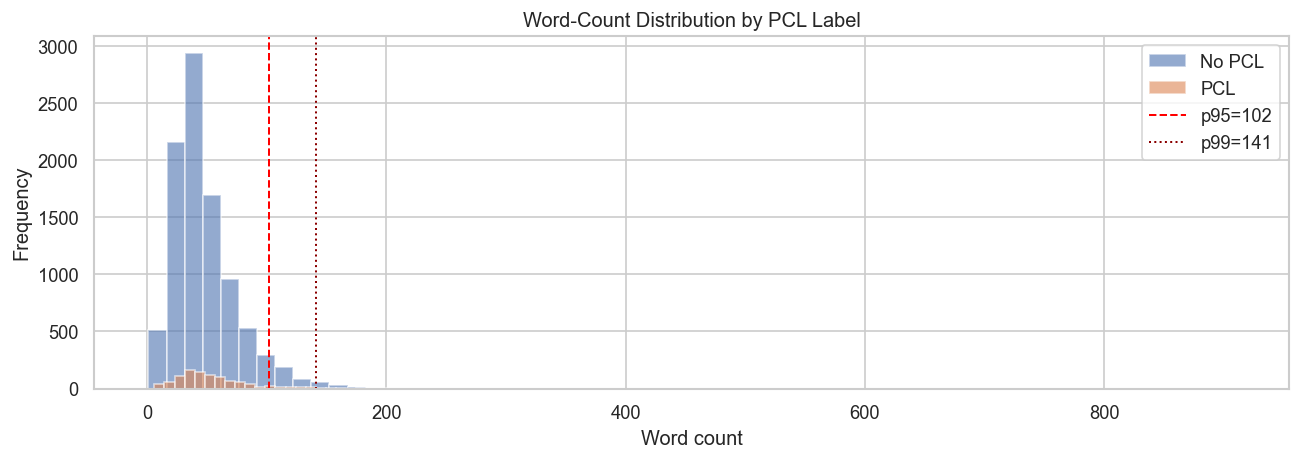

p95=102 words  |  p99=141 words


In [189]:
# Word-count histogram with p95 / p99 cut-offs
p95 = int(df_split["text_len_words"].quantile(0.95))
p99 = int(df_split["text_len_words"].quantile(0.99))

fig, ax = plt.subplots(figsize=(11, 4))
for v, c, lbl in [(0,"#4c72b0","No PCL"),(1,"#dd8452","PCL")]:
    ax.hist(df_split[df_split.pcl==v]["text_len_words"], bins=60, alpha=0.6, color=c, label=lbl)
ax.axvline(p95, color="red",     ls="--", lw=1.2, label=f"p95={p95}")
ax.axvline(p99, color="darkred", ls=":",  lw=1.2, label=f"p99={p99}")
ax.set(xlabel="Word count", ylabel="Frequency",
       title="Word-Count Distribution by PCL Label")
ax.legend(); plt.tight_layout()
plt.savefig("report/figures/wordcount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"p95={p95} words  |  p99={p99} words")


#### Duplicates and Noise

In [190]:
# Duplicate & leakage check
n_dup      = df_split["text"].duplicated().sum()
n_leakage  = len(set(df_train["text"]) & set(df_test["text"]))
dup_df     = df_split[df_split.duplicated(subset=["text"], keep=False)]
n_conflict = dup_df.groupby("text")["pcl"].nunique().gt(1).sum() if n_dup else 0

print(f"Exact duplicates:          {n_dup}  ({n_dup/len(df_split)*100:.2f}%)")
print(f"Train→Dev text leakage:    {n_leakage}")
print(f"Duplicates with label conflict: {n_conflict}")


Exact duplicates:          0  (0.00%)
Train→Dev text leakage:    0
Duplicates with label conflict: 0


In [191]:
# Noise artefact scan
patterns = {
    "HTML entities":    r'&\w+;',
    "URLs":             r'https?://\S+',
    "Long digit runs":  r'\b\d{4,}\b',
    "Non-ASCII":        r'[^\x00-\x7F]',
    "Double spaces":    r'  +',
}
rows = [{"Artefact": k,
         "Paragraphs": (n := df_split["text"].str.contains(v,regex=True).sum()),
         "%": round(n/len(df_split)*100,2)}
        for k,v in patterns.items()]
pd.DataFrame(rows)


,Artefact,Paragraphs,%
0,HTML entities,78,0.75
1,URLs,0,0.00
2,Long digit runs,1025,9.79
3,Non-ASCII,0,0.00
4,Double spaces,0,0.00


### Technique 2: Lexical Analysis

Comparing top unigrams and bigrams for PCL vs. non-PCL paragraphs, after removing stopwords. This reveals whether the model can exploit discriminative surface patterns or whether such shortcut features exist and could cause spurious correlations.

In [192]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, n, k=20):
    vec = CountVectorizer(ngram_range=(n,n), stop_words="english", max_features=5000)
    X   = vec.fit_transform(texts)
    counts = X.sum(axis=0).A1
    return pd.Series(counts, index=vec.get_feature_names_out()).nlargest(k)

pcl_texts   = df_split[df_split.pcl==1]["text"].dropna().tolist()
nopcl_texts = df_split[df_split.pcl==0]["text"].dropna().tolist()

uni_pcl,  uni_nopcl = top_ngrams(pcl_texts,1), top_ngrams(nopcl_texts,1)
bi_pcl,   bi_nopcl  = top_ngrams(pcl_texts,2), top_ngrams(nopcl_texts,2)


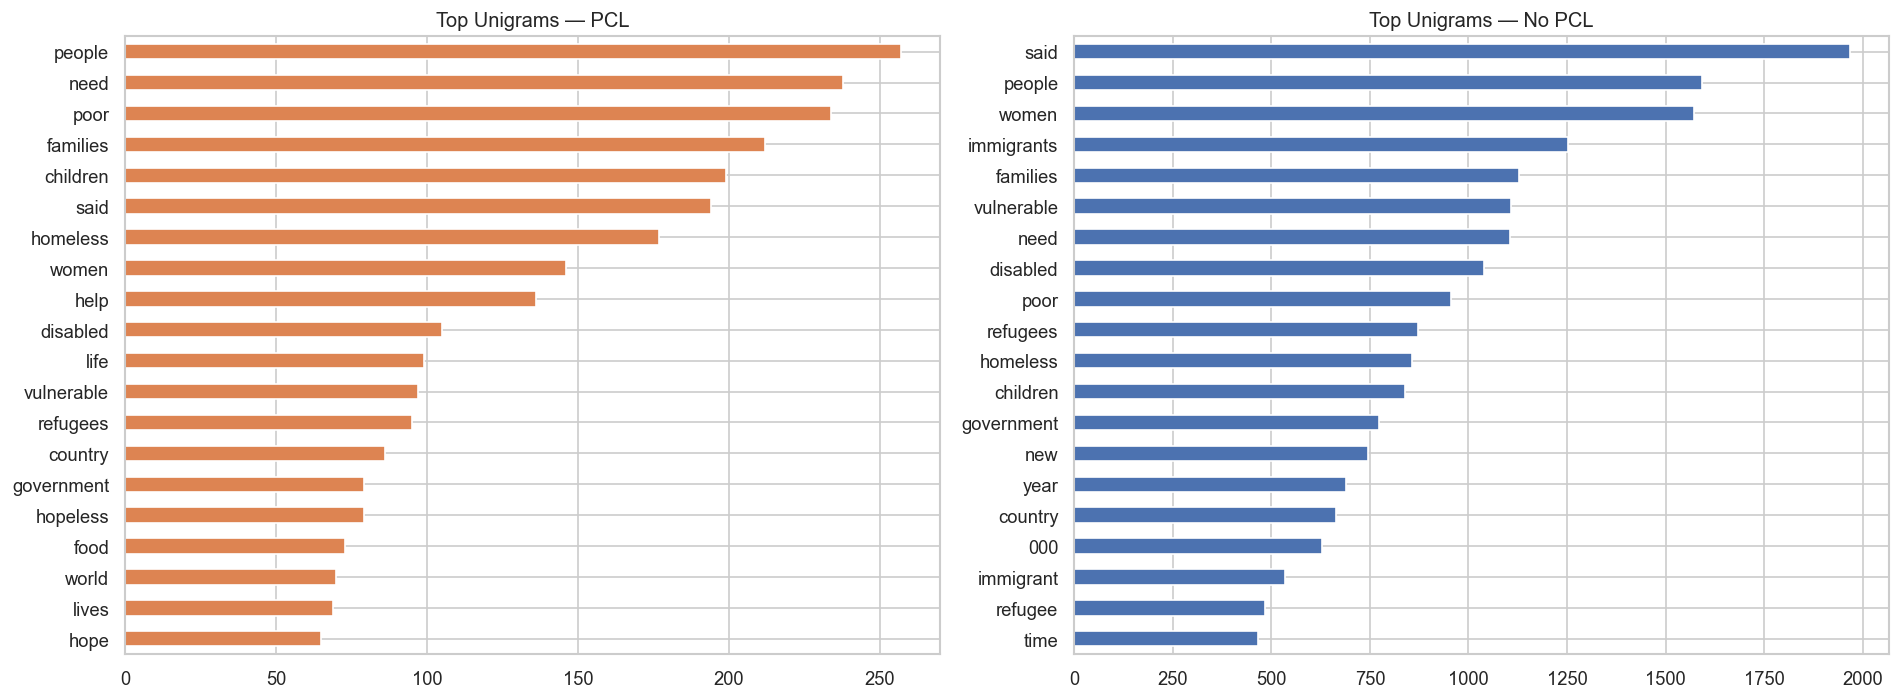

In [193]:
# Top-20 unigrams: PCL vs No-PCL
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
uni_pcl.sort_values().plot.barh(ax=axes[0], color="#dd8452")
axes[0].set_title("Top Unigrams — PCL")
uni_nopcl.sort_values().plot.barh(ax=axes[1], color="#4c72b0")
axes[1].set_title("Top Unigrams — No PCL")
plt.tight_layout()
plt.savefig("report/figures/unigrams.png", dpi=150, bbox_inches="tight")
plt.show()


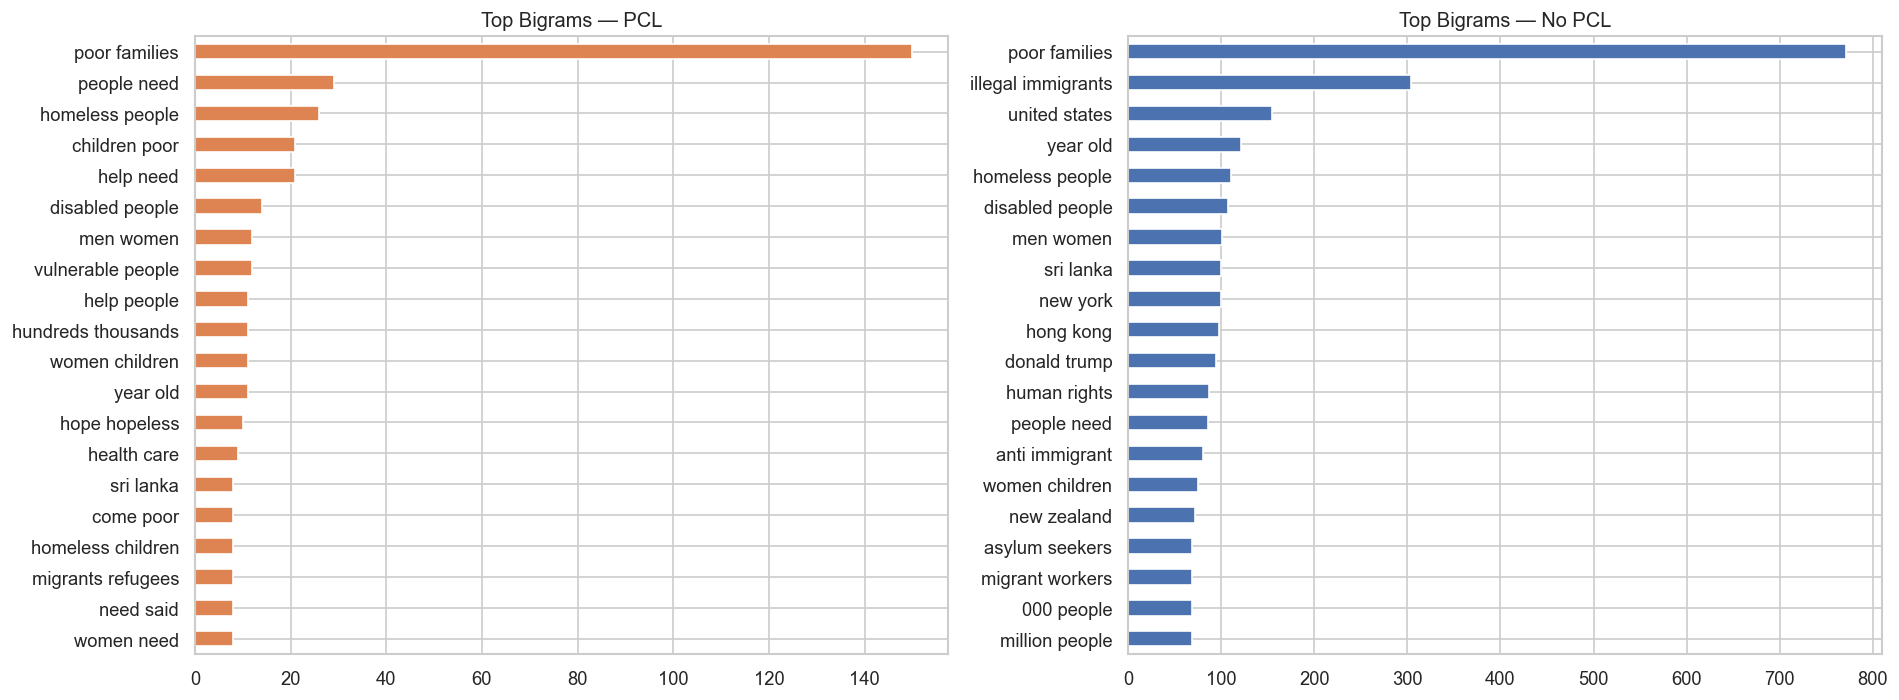

In [194]:
# Top-20 bigrams: PCL vs No-PCL
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bi_pcl.sort_values().plot.barh(ax=axes[0], color="#dd8452")
axes[0].set_title("Top Bigrams — PCL")
bi_nopcl.sort_values().plot.barh(ax=axes[1], color="#4c72b0")
axes[1].set_title("Top Bigrams — No PCL")
plt.tight_layout()
plt.savefig("report/figures/bigrams.png", dpi=150, bbox_inches="tight")
plt.show()


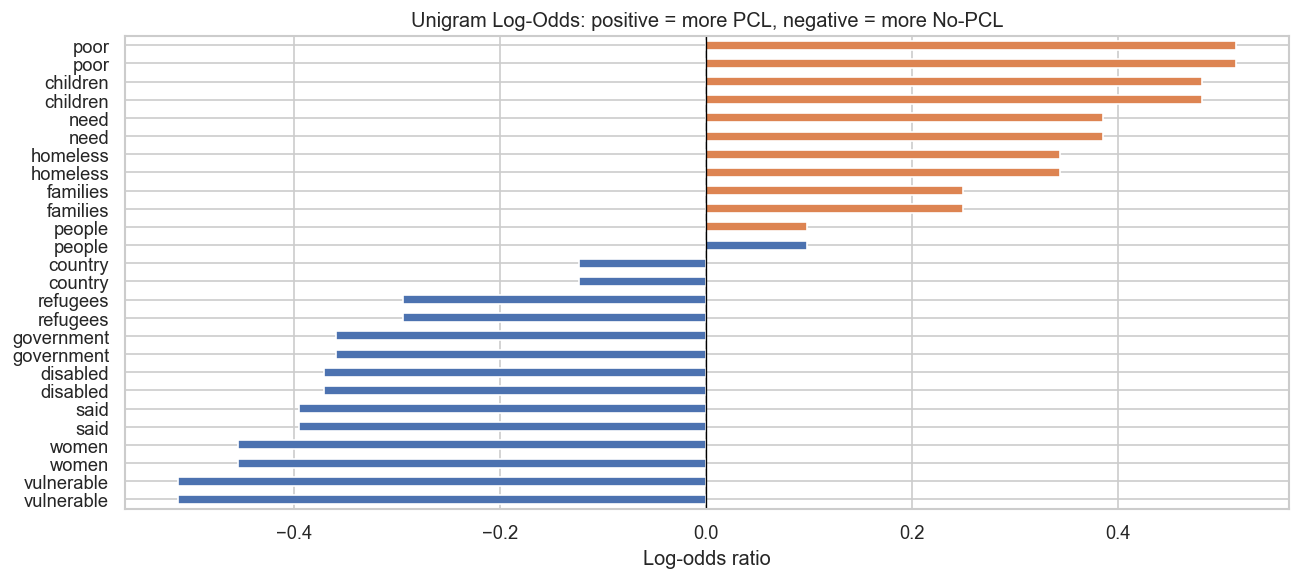

In [195]:
# Most distinctive unigrams by log-odds ratio (PCL vs No-PCL)
shared = uni_pcl.index.intersection(uni_nopcl.index)
log_odds = np.log((uni_pcl[shared] / uni_pcl[shared].sum()) /
                  (uni_nopcl[shared] / uni_nopcl[shared].sum()))

fig, ax = plt.subplots(figsize=(11, 5))
pd.concat([log_odds.nlargest(15), log_odds.nsmallest(15)]).sort_values().plot.barh(
    ax=ax, color=["#4c72b0"]*15 + ["#dd8452"]*15)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Unigram Log-Odds: positive = more PCL, negative = more No-PCL",
       xlabel="Log-odds ratio")
plt.tight_layout()
plt.savefig("report/figures/log_odds.png", dpi=150, bbox_inches="tight")
plt.show()
